In [69]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
from datetime import date
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather, InitialConditions

from aquacrop_slovenia import config
from aquacrop_slovenia.prepare_weather import load_station_weather
from aquacrop_slovenia.intial_conditions_defaults import intial_cond_params
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_gdd_and_yield, \
    plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop
from aquacrop_slovenia.parameter_defaults_jablje import jablje_soil_layers, jablje_curve_number, jablje_readily_evaporable_water, jablje_maize_params, optimal_management
from aquacrop_slovenia.diagnostics import nse, kge, mkge

In [71]:
# Set up working directory for outputs
output_dir = config.MODELS_DIR / "testing"
LOCATION = "jablje"

plant and end dates are set to be the same every year - TODO TEMPORARY!!!

We exclude 2017 since we dont have ET data for most of the year

In [72]:
#year = 1993
simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 10, 10), # TODO temporary
        "planting_date": date(year, 5, 3), # TODO temporary
        "is_seeding_year": True,
    }
#]
for year in range(1993, 2024) if year not in [2017]]

In [73]:
jablje_temperatures, jablje_eto, jablje_rain = load_station_weather(8) # Jablje uses ARSO meteo station 8 data

In [74]:
historical_co2 = get_co2_for_aquacrop("historical")

In [75]:
jablje_weather = Weather(
    location=LOCATION,
    temperatures=jablje_temperatures,
    eto_values=jablje_eto,
    rainfall_values=jablje_rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2
)

In [76]:
jablje_maize = Crop(
    name=f"{LOCATION} maize",
    description=f"{LOCATION} maize uncalibrated",
    params=jablje_maize_params
)

In [77]:
jablje_soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} silt loam soil uncalibrated",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water
)

In [78]:
default_initial_conditions = InitialConditions(
    name="DefaultInitialConditions",
    description="Default initial conditions with AquaCrop calculated defaults",
    params=intial_cond_params
)

In [79]:
# Create AquaCrop simulation
simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=jablje_maize,
    soil=jablje_soil,
    management=optimal_management,
    initial_conditions=default_initial_conditions,
    climate=jablje_weather,
    working_dir=output_dir,
    need_daily_output=True,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False
)

In [80]:
# Run the simulation
results = simulation.run()
seasonal_results = results["season"]

Setting up working directory at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing
Running AquaCrop simulation with project file: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing\LIST\PROJECT.PRM
Detected platform: windows (AMD64)
Looking for executable at: C:\Users\rokku\Documents\Code\aquacrop-slovenia\.venv\Lib\site-packages\model\windows\aquacrop.exe
Using AquaCrop executable: C:\Users\rokku\Documents\Code\aquacrop-slovenia\models\testing\aquacrop.exe
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [81]:
seasonal_results

,RunNr,Day1,Month1,Year1,Rain,ETo,GD,CO2,Irri,Infilt,...,HI,Y(dry),Y(fresh),WPet,Bin,Bout,DayN,MonthN,YearN,Project
0,1,1,1,1993,765.3,723.8,1099.9,355.97,0.0,645.7,...,37.8,7.762,8.624,2.45,0.0,0.0,10,10,1993,PROJECT.PRM
1,2,1,1,1994,1019.4,706.5,1203.3,357.58,0.0,882.0,...,43.4,10.477,11.641,2.70,0.0,0.0,10,10,1994,PROJECT.PRM
2,3,1,1,1995,1199.6,647.7,989.3,359.53,0.0,943.0,...,43.4,8.809,9.788,2.79,0.0,0.0,10,10,1995,PROJECT.PRM
3,4,1,1,1996,1087.0,603.8,965.7,361.26,0.0,850.3,...,37.3,7.342,8.158,2.34,0.0,0.0,10,10,1996,PROJECT.PRM
4,5,1,1,1997,740.0,683.6,1095.2,362.43,0.0,646.4,...,42.6,9.783,10.870,2.89,0.0,0.0,10,10,1997,PROJECT.PRM
5,6,1,1,1998,1068.3,671.4,1180.7,365.14,0.0,875.6,...,37.4,8.877,9.863,2.64,0.0,0.0,10,10,1998,PROJECT.PRM
6,7,1,1,1999,1089.3,642.0,1192.4,366.96,0.0,890.3,...,43.4,9.806,10.896,2.85,0.0,0.0,10,10,1999,PROJECT.PRM
7,8,1,1,2000,869.7,704.3,1172.3,368.25,0.0,756.7,...,33.7,7.157,7.952,1.98,0.0,0.0,10,10,2000,PROJECT.PRM
8,9,1,1,2001,1054.2,661.7,1127.3,369.65,0.0,863.6,...,43.4,9.944,11.048,2.78,0.0,0.0,10,10,2001,PROJECT.PRM
9,10,1,1,2002,865.7,643.0,1132.7,371.87,0.0,756.5,...,43.4,10.605,11.783,2.91,0.0,0.0,10,10,2002,PROJECT.PRM


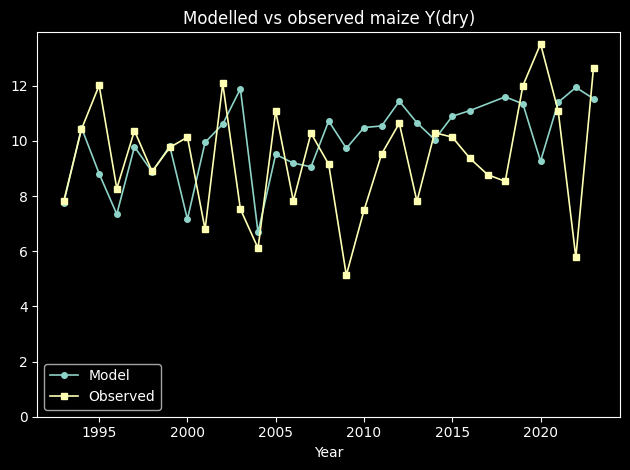

In [82]:
plot_yield_timeseries_comparison(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

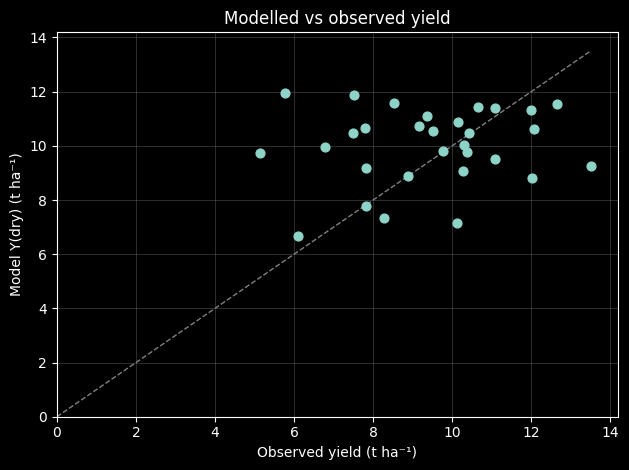

In [83]:
plot_yield_scatter(seasonal_results, get_yield(LOCATION, "grain", "A", "N3"))

In [84]:
print(root_mean_squared_error(results["season"][["Year1", "Y(dry)"]], get_yield_for_comparison(LOCATION, "grain", "A", "N3")))
print(r2_score(results["season"][["Year1", "Y(dry)"]], get_yield_for_comparison(LOCATION, "grain", "A", "N3")))
print(nse(results["season"]["Y(dry)"].values, get_yield_for_comparison(LOCATION, "grain", "A", "N3")["yield"].values))
print(kge(results["season"]["Y(dry)"].values, get_yield_for_comparison(LOCATION, "grain", "A", "N3")["yield"].values))
print(mkge(results["season"]["Y(dry)"].values, get_yield_for_comparison(LOCATION, "grain", "A", "N3")["yield"].values))

1.193422131239962
-0.46310253932510825
-0.3530285424679469
0.07766756510729844
0.06349984395431074


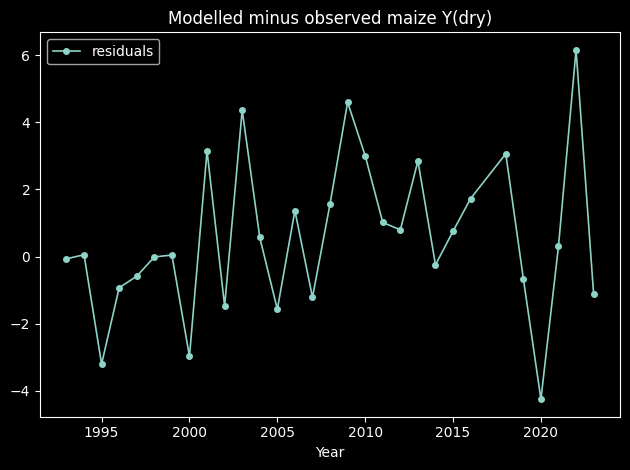

In [85]:
plot_yield_timeseries_residuals(seasonal_results, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

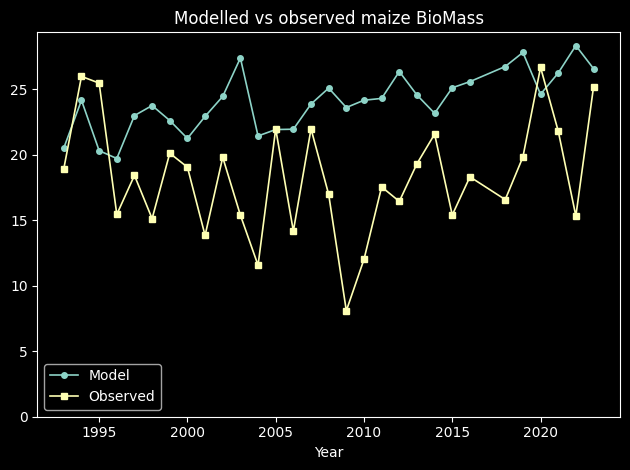

In [86]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "biomass", "A", "N3"), "BioMass")

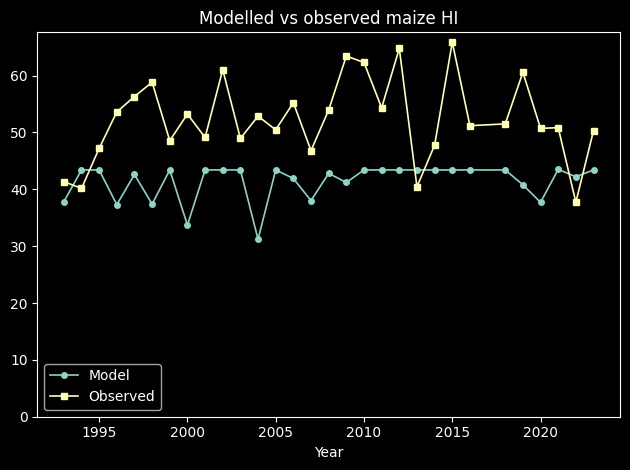

In [87]:
plot_yield_timeseries_comparison(seasonal_results, get_yield_for_comparison(LOCATION, "hi", "A", "N3"), "HI")

In [88]:
results["day"]

,Day,Month,Year,DAP,Stage,WC(2.30),Rain,Irri,Surf,Infilt,...,9_1,ECe10,ECe11,ECe12,Rain_1,ETo,Tmin,Tavg,Tmax,CO2
0,1,1,1993,-9,0,758.7,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
1,2,1,1993,-9,0,758.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
2,3,1,1993,-9,0,757.4,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
3,4,1,1993,-9,0,757.1,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
4,5,1,1993,-9,0,756.9,0.0,0.0,0.0,0.0,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,6,10,1993,-9,0,759.8,2.4,0.0,0.0,2.4,...,None,None,None,None,None,None,None,None,None,None
279,7,10,1993,-9,0,783.7,47.0,0.0,0.0,26.6,...,None,None,None,None,None,None,None,None,None,None
280,8,10,1993,-9,0,780.5,7.3,0.0,0.0,6.8,...,None,None,None,None,None,None,None,None,None,None
281,9,10,1993,-9,0,786.2,26.0,0.0,0.0,17.8,...,None,None,None,None,None,None,None,None,None,None


<Axes: >

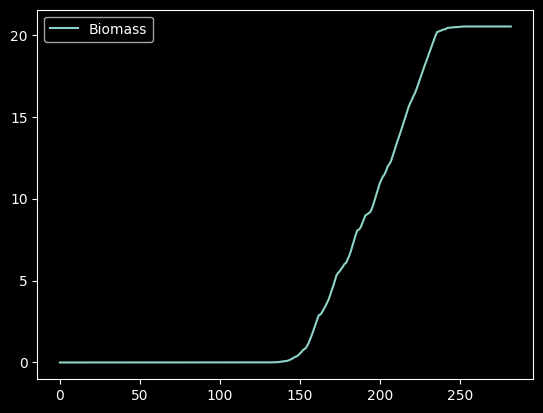

In [89]:
results["day"].plot(y="Biomass")

<Axes: >

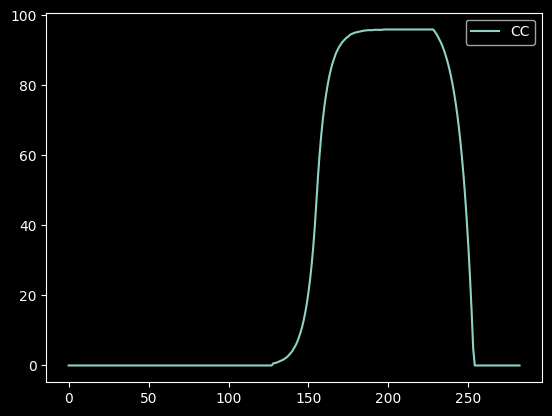

In [90]:
results["day"].plot(y="CC")

<Axes: >

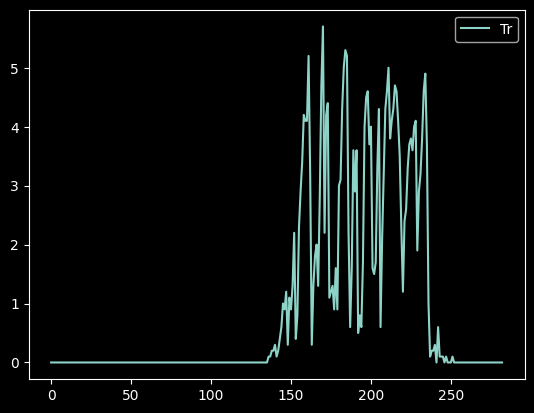

In [91]:
results["day"].plot(y="Tr")

<Axes: >

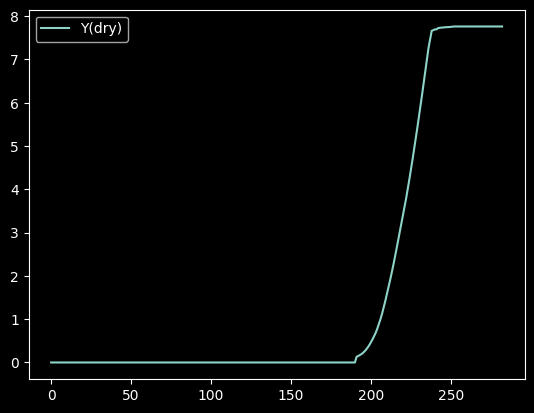

In [92]:
results["day"].plot(y="Y(dry)")

In [93]:
from aquacrop_slovenia.diagnostics import compute_annual_gdd

base_temp = jablje_maize_params['base_temp']
upper_temp = jablje_maize_params['upper_temp']

gdd_by_year = compute_annual_gdd(8, base_temp, upper_temp)
gdd_by_year

year
1993    1135.15
1994    1207.50
1995    1017.15
1996     992.30
1997    1104.35
1998    1200.05
1999    1238.65
2000    1231.10
2001    1163.85
2002    1176.50
2003    1383.40
2004    1084.70
2005    1144.40
2006    1176.40
2007    1214.00
2008    1226.90
2009    1301.60
2010    1148.65
2011    1315.70
2012    1363.10
2013    1294.15
2014    1283.90
2015    1336.40
2016    1290.90
2017    1276.85
2018    1548.75
2019    1342.40
2020    1251.40
2021    1239.20
2022    1489.50
2023    1440.80
Name: gdd, dtype: float64

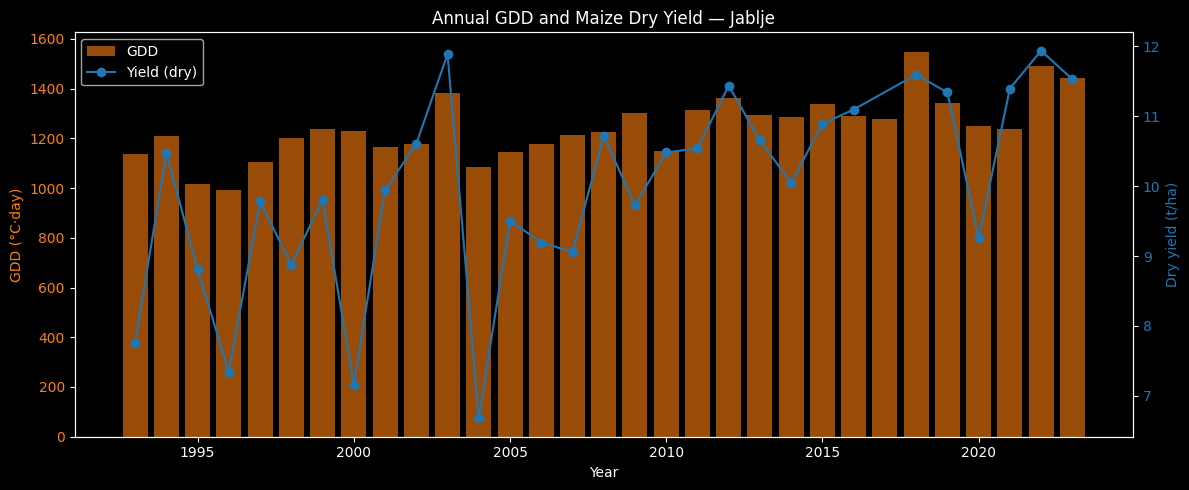

In [94]:
plot_gdd_and_yield(gdd_by_year, results["season"], title="Annual GDD and Maize Dry Yield — Jablje")